# Image classification with fastai

In this workshop we will learn to build state of the art models for classification really fast with [fastai](https://www.fast.ai/). The structure of the workshop will be the follwing:



1.   Load and explore data
2.   Train the model
3.   Evaluate results

In [1]:
from fastai.vision.all import *
import warnings
warnings.filterwarnings("ignore")

## Single label classification

### Binary classification

In [2]:
# Download data
path = untar_data(URLs.PETS)

In [3]:
path.ls()

(#2) [Path('/root/.fastai/data/oxford-iiit-pet/images'),Path('/root/.fastai/data/oxford-iiit-pet/annotations')]

In [4]:
files = get_image_files(path/"images")
len(files)

7390

In [5]:
files[0],files[3], files[0]

(Path('/root/.fastai/data/oxford-iiit-pet/images/scottish_terrier_128.jpg'),
 Path('/root/.fastai/data/oxford-iiit-pet/images/pug_66.jpg'),
 Path('/root/.fastai/data/oxford-iiit-pet/images/scottish_terrier_128.jpg'))

In [6]:
def label_func(file_name): return file_name[0].isupper()

In [7]:
# Load data
dls = ImageDataLoaders.from_name_func(path, files, label_func, item_tfms=Resize(224))

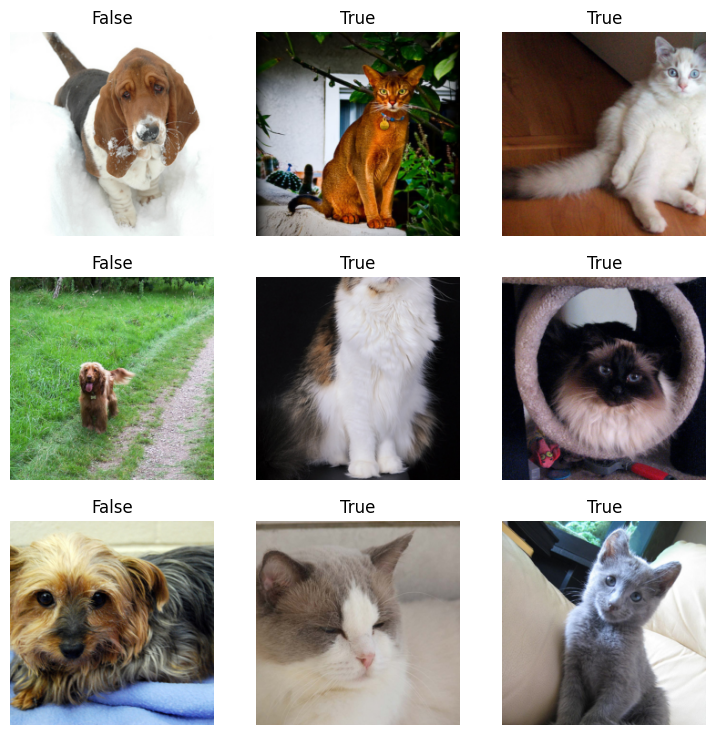

In [8]:
# Show batch of data
dls.show_batch()

In [9]:
# Initialize model
learn = vision_learner(dls, resnet34, metrics=error_rate)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 140MB/s]


In [10]:
# Train model
learn.fine_tune(1)

epoch,train_loss,valid_loss,error_rate,time
0,0.143909,0.020233,0.007442,00:48


epoch,train_loss,valid_loss,error_rate,time
0,0.053385,0.038150,0.009472,00:54


In [11]:
# Predict one sample
learn.predict(files[0])

('False', tensor(0), tensor([1.0000e+00, 1.8266e-08]))

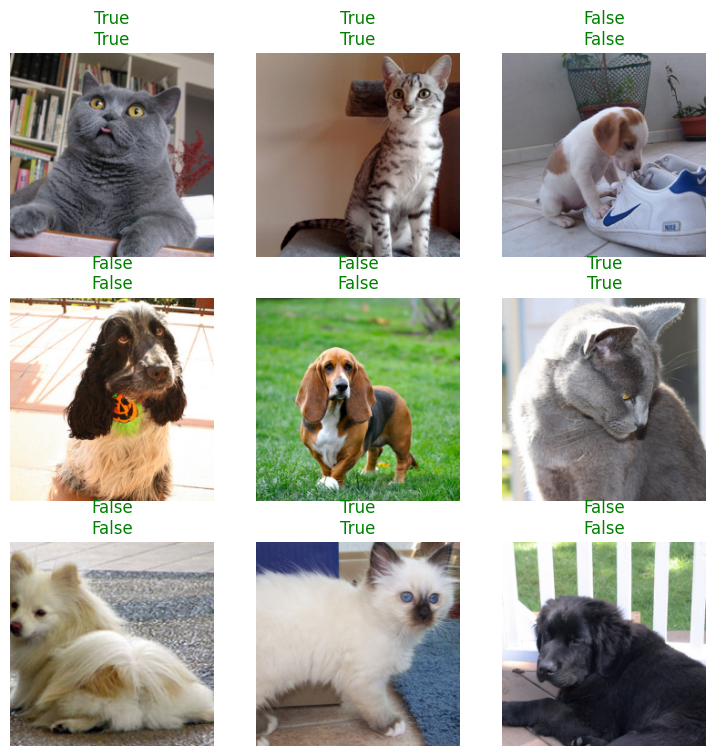

In [12]:
# Show a batch of predictions
learn.show_results()

### Multi class classification

In [13]:
files[0].name

'scottish_terrier_128.jpg'

In [14]:
def label_func(file_name): return ('_').join(file_name.split('_')[:-1])

In [15]:
label_func(files[0].name)

'scottish_terrier'

In [16]:
# Load data
dls = ImageDataLoaders.from_name_func(path, files, label_func, item_tfms=Resize(224))

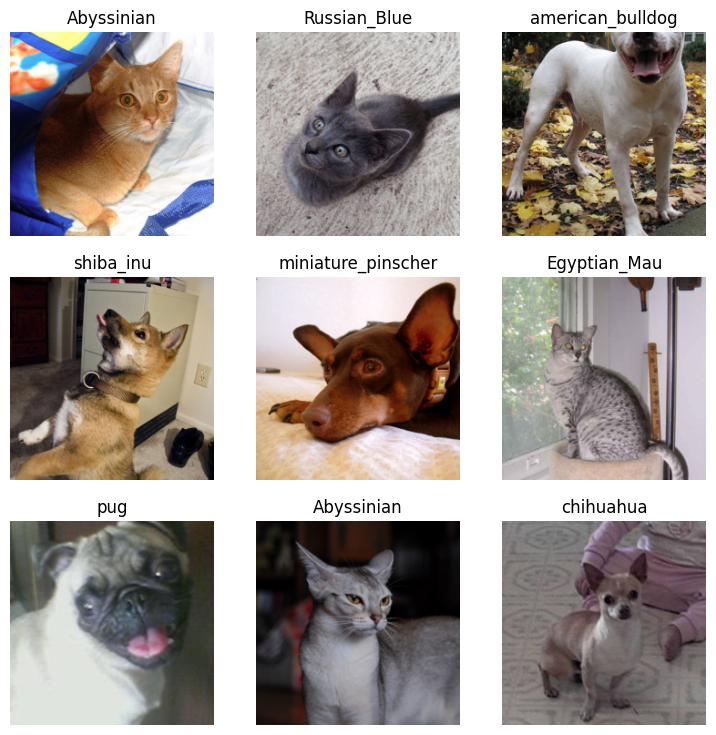

In [17]:
# Show batch
dls.show_batch()

In [18]:
# Load data with data augmentation
dls = ImageDataLoaders.from_name_func(path, files, label_func, item_tfms=Resize(460),
                                    batch_tfms=aug_transforms(size=224))

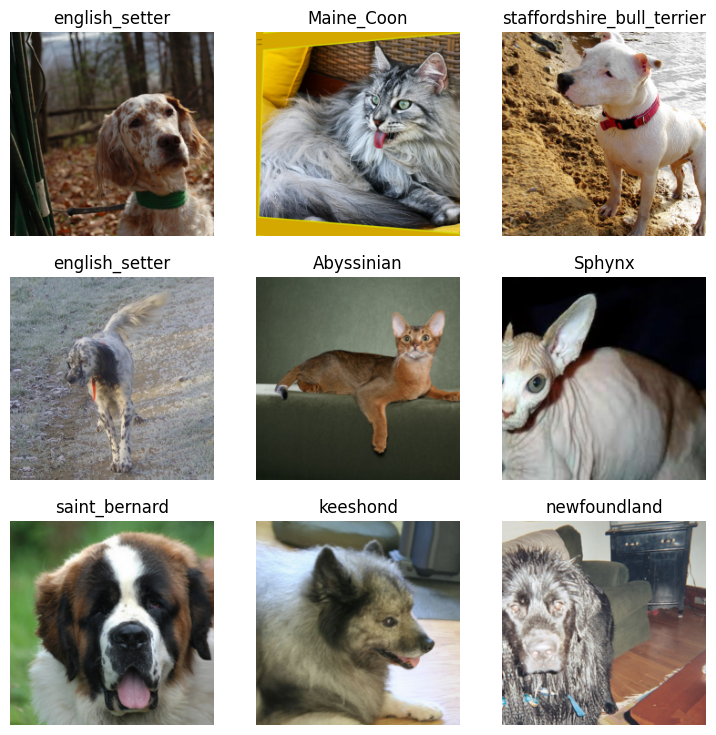

In [19]:
# Show batch
dls.show_batch()

In [20]:
# Initialize model
learn = vision_learner(dls, resnet34, metrics=error_rate)

SuggestedLRs(valley=0.0008317637839354575)

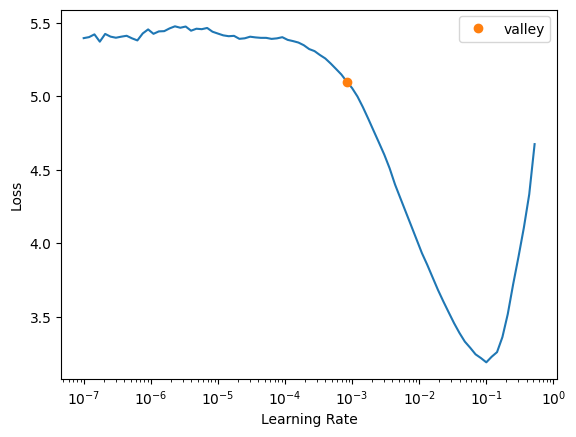

In [21]:
# Find LR
learn.lr_find()

In [22]:
# Train model
learn.fine_tune(2, 5e-3)

epoch,train_loss,valid_loss,error_rate,time
0,1.096572,0.349875,0.110284,01:10


epoch,train_loss,valid_loss,error_rate,time
0,0.656129,0.554999,0.148173,01:10
1,0.386933,0.219590,0.070365,01:11


In [23]:
learn.save('manolo')

Path('/root/.fastai/data/oxford-iiit-pet/models/manolo.pth')

SuggestedLRs(valley=7.585775892948732e-05)

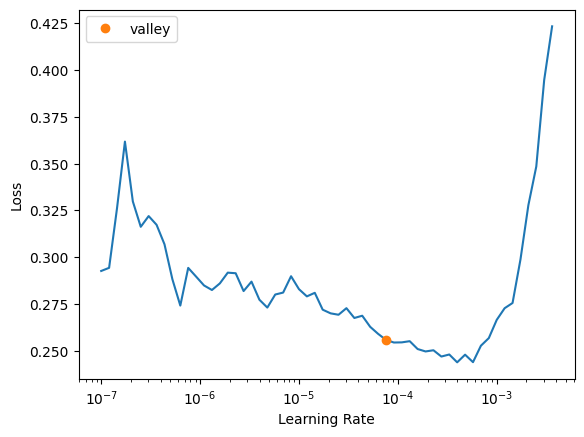

In [24]:
learn.lr_find()

In [25]:
learn.fine_tune(2, 3e-5)

epoch,train_loss,valid_loss,error_rate,time
0,0.229210,0.213357,0.067659,01:10


epoch,train_loss,valid_loss,error_rate,time
0,0.219999,0.211244,0.071719,01:09
1,0.214643,0.212303,0.066982,01:11


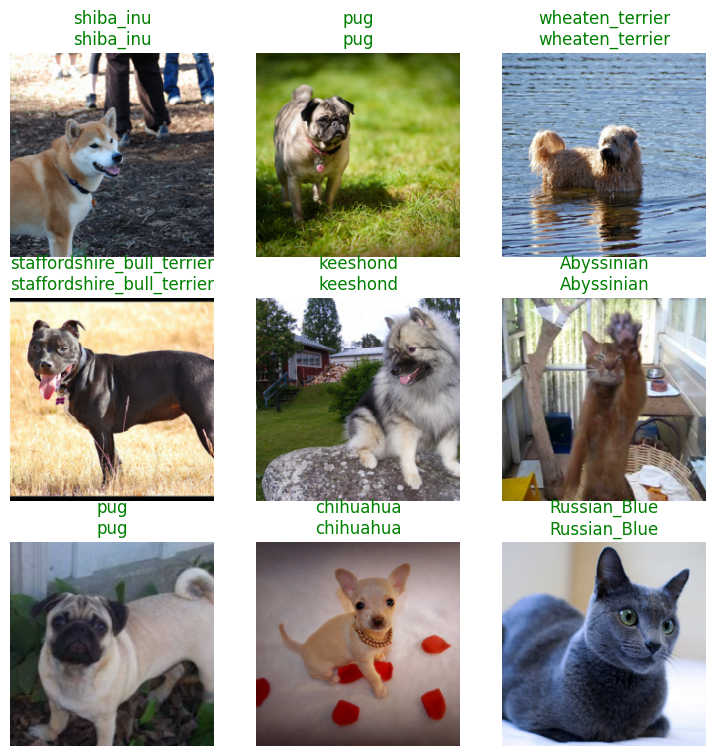

In [26]:
# Show a batch of predictions
learn.show_results()

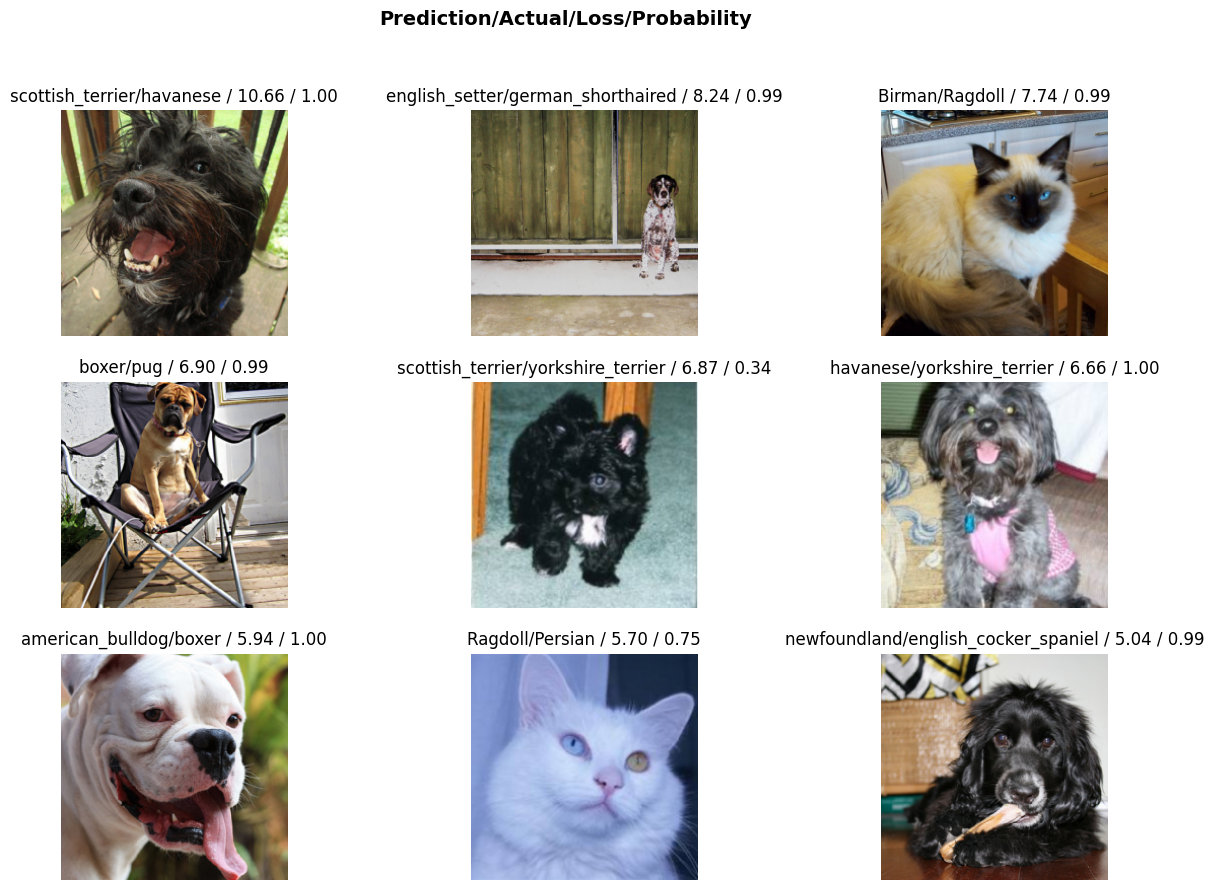

In [27]:
# Show worst classified images
interp = Interpretation.from_learner(learn)
interp.plot_top_losses(9, figsize=(15,10))

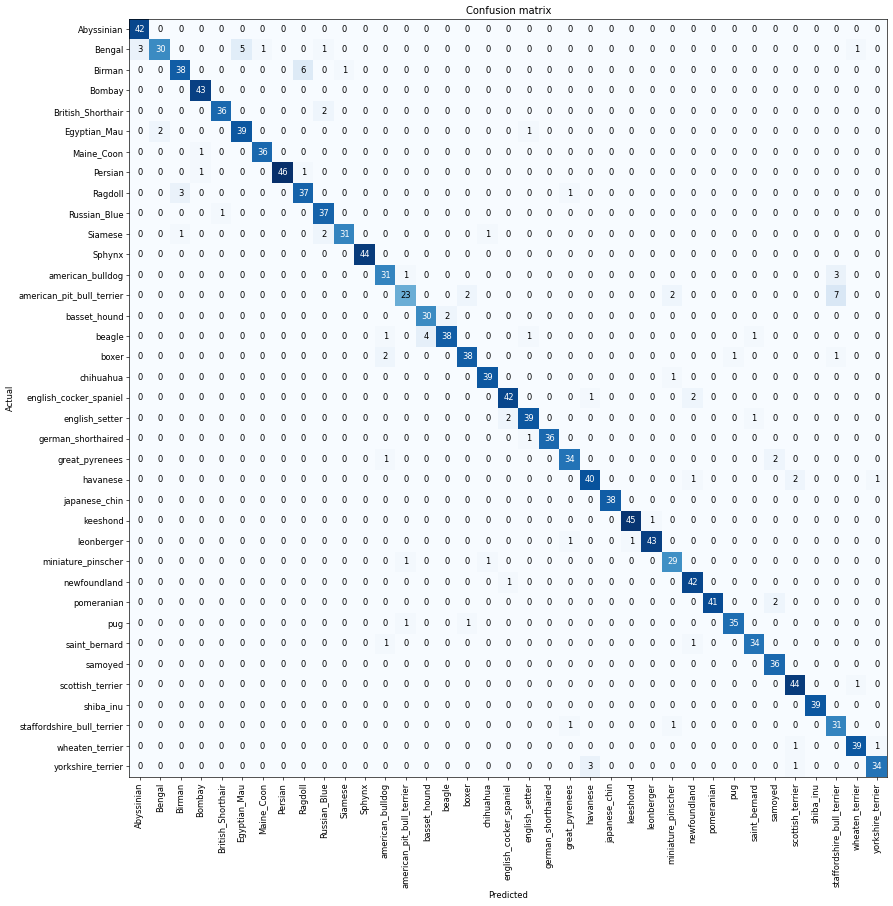

In [28]:
# Show confusion matrix
classification_interp = ClassificationInterpretation.from_learner(learn)
classification_interp.plot_confusion_matrix(figsize=(15,15), dpi=60)

In [29]:
# Show most confused classes
classification_interp.most_confused(min_val=2)

[('american_pit_bull_terrier', 'staffordshire_bull_terrier', 7),
 ('Birman', 'Ragdoll', 6),
 ('Bengal', 'Egyptian_Mau', 5),
 ('beagle', 'basset_hound', 4),
 ('Bengal', 'Abyssinian', 3),
 ('Ragdoll', 'Birman', 3),
 ('american_bulldog', 'staffordshire_bull_terrier', 3),
 ('yorkshire_terrier', 'havanese', 3),
 ('British_Shorthair', 'Russian_Blue', 2),
 ('Egyptian_Mau', 'Bengal', 2),
 ('Siamese', 'Russian_Blue', 2),
 ('american_pit_bull_terrier', 'boxer', 2),
 ('american_pit_bull_terrier', 'miniature_pinscher', 2),
 ('basset_hound', 'beagle', 2),
 ('boxer', 'american_bulldog', 2),
 ('english_cocker_spaniel', 'newfoundland', 2),
 ('english_setter', 'english_cocker_spaniel', 2),
 ('great_pyrenees', 'samoyed', 2),
 ('havanese', 'scottish_terrier', 2),
 ('pomeranian', 'samoyed', 2)]

## Multi-label classification

In [30]:
# Download data
path = untar_data(URLs.PASCAL_2007)
path.ls()

(#8) [Path('/root/.fastai/data/pascal_2007/train'),Path('/root/.fastai/data/pascal_2007/train.csv'),Path('/root/.fastai/data/pascal_2007/valid.json'),Path('/root/.fastai/data/pascal_2007/test'),Path('/root/.fastai/data/pascal_2007/test.csv'),Path('/root/.fastai/data/pascal_2007/test.json'),Path('/root/.fastai/data/pascal_2007/train.json'),Path('/root/.fastai/data/pascal_2007/segmentation')]

In [31]:
df = pd.read_csv(path/'train.csv')
df.head()

,fname,labels,is_valid
0,000005.jpg,chair,True
1,000007.jpg,car,True
2,000009.jpg,horse person,True
3,000012.jpg,car,False
4,000016.jpg,bicycle,True


In [32]:
# Load data
dls = ImageDataLoaders.from_df(df, path, folder='train', valid_col='is_valid', label_delim=' ',
                               item_tfms=Resize(460), batch_tfms=aug_transforms(size=224))

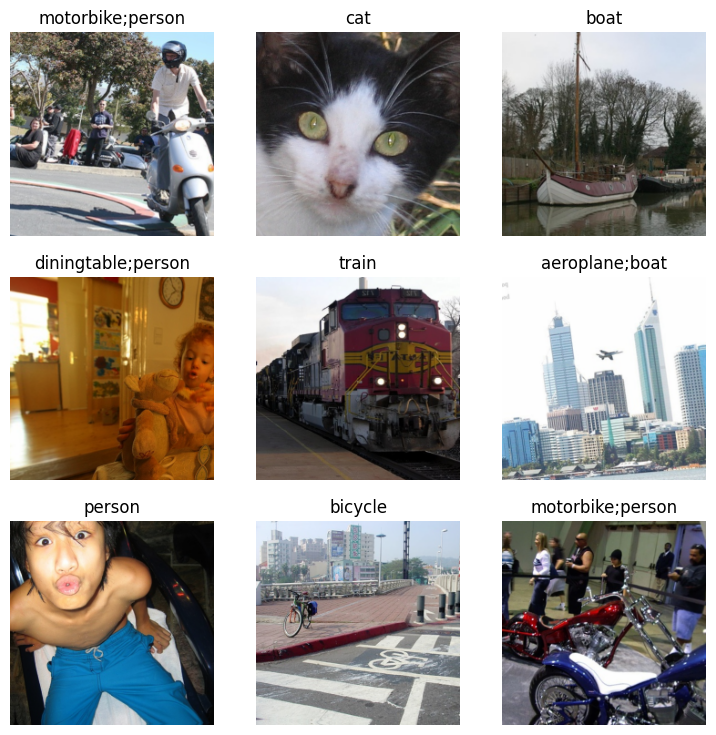

In [33]:
# Show batch
dls.show_batch()

In [34]:
# Initialize learn with F1 score for multi-label problems as metric
f1_macro = F1ScoreMulti(thresh=0.5, average='macro')
f1_macro.name = 'F1(macro)'
f1_samples = F1ScoreMulti(thresh=0.5, average='samples')
f1_samples.name = 'F1(samples)'
learn = vision_learner(dls, resnet50, metrics=[f1_macro, f1_samples])

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 147MB/s]


SuggestedLRs(valley=0.001737800776027143)

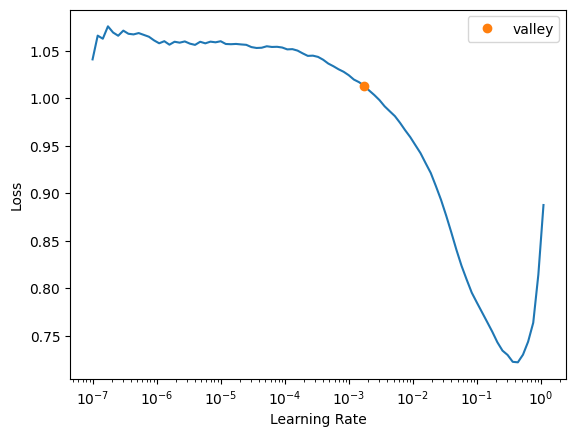

In [35]:
learn.lr_find()

In [36]:
# Train the model
learn.fine_tune(5, 3e-2)

epoch,train_loss,valid_loss,F1(macro),F1(samples),time
0,0.441858,0.118262,0.665989,0.727476,00:50


epoch,train_loss,valid_loss,F1(macro),F1(samples),time
0,0.115038,0.131917,0.706924,0.747553,00:51
1,0.125593,0.223474,0.464027,0.515616,00:53
2,0.122661,0.120451,0.653145,0.682347,00:51
3,0.099515,0.091714,0.727368,0.754045,00:54
4,0.075444,0.086493,0.751176,0.774520,00:50


,target,predicted,probabilities,loss
0,cat;pottedplant,cat,"tensor([2.4652e-16, 4.5280e-12, 3.0289e-14, 6.3689e-16, 3.6421e-06, 4.7376e-17,\n 3.1198e-11, 1.0000e+00, 1.4925e-07, 1.2876e-16, 5.1640e-07, 3.2509e-11,\n 5.5443e-10, 1.6385e-14, 5.8546e-07, 5.1043e-09, 2.7290e-17, 9.8109e-12,\n 2.2881e-20, 2.1590e-11])",0.9546604156494141
1,bus;car,boat,"tensor([2.0035e-02, 1.2670e-04, 8.0366e-05, 9.6902e-01, 2.1584e-04, 7.5519e-05,\n 8.7586e-03, 1.0884e-04, 3.8464e-04, 2.7609e-03, 2.3530e-05, 8.6522e-05,\n 1.8574e-05, 7.5195e-05, 5.7977e-02, 8.0385e-03, 1.0148e-04, 1.7388e-04,\n 2.1312e-03, 2.6569e-04])",0.8898868560791016
2,bicycle;chair;diningtable,bicycle,"tensor([2.3448e-06, 9.9998e-01, 3.0562e-05, 1.0644e-05, 1.3694e-02, 1.4503e-03,\n 9.7415e-03, 5.9952e-07, 1.4492e-03, 6.2086e-07, 1.1846e-04, 1.4769e-05,\n 1.1888e-05, 1.1628e-05, 2.0741e-03, 2.2704e-03, 2.3000e-05, 3.0855e-05,\n 1.1957e-05, 8.6580e-05])",0.7803642749786377
3,car;person;train,car,"tensor([4.0745e-06, 1.1598e-04, 8.5142e-05, 2.2415e-04, 2.0192e-05, 1.7490e-05,\n 9.9991e-01, 4.1839e-06, 3.8141e-04, 1.5537e-05, 2.0994e-06, 1.0845e-04,\n 8.0620e-06, 5.7909e-05, 7.3735e-02, 2.5354e-04, 3.8831e-05, 8.9010e-05,\n 2.3319e-05, 6.0833e-05])",0.6637552380561829
4,bottle;cow;person,chair;person;sofa,"tensor([8.5815e-04, 9.4946e-03, 3.0786e-03, 1.7206e-03, 4.6351e-02, 2.3142e-03,\n 2.2895e-02, 6.2087e-03, 5.9269e-01, 6.3600e-04, 1.6799e-02, 1.5436e-02,\n 2.1889e-02, 1.7553e-02, 9.8871e-01, 1.7253e-01, 8.9981e-04, 6.5081e-01,\n 1.0879e-03, 1.9199e-02])",0.6361755728721619
5,bicycle;person,aeroplane,"tensor([9.8997e-01, 2.2971e-03, 5.2998e-04, 2.5283e-03, 1.1215e-03, 2.1212e-02,\n 3.0227e-01, 1.3333e-04, 2.3366e-03, 4.1919e-03, 1.3166e-04, 2.3665e-03,\n 9.8688e-04, 4.3172e-03, 2.3173e-01, 1.3625e-03, 3.2540e-02, 5.0748e-04,\n 6.0803e-04, 4.0273e-03])",0.6290173530578613
6,bicycle;car;person,car,"tensor([4.5068e-07, 1.2088e-04, 2.8294e-05, 1.2583e-04, 2.4538e-05, 9.5689e-06,\n 9.9999e-01, 3.2947e-06, 1.2549e-04, 3.3737e-06, 9.1806e-07, 2.0010e-05,\n 8.9965e-07, 1.3011e-04, 4.9364e-02, 1.2427e-04, 6.8063e-06, 3.8688e-05,\n 3.9636e-06, 2.7909e-05])",0.6014987826347351
7,horse;person,,"tensor([1.9791e-04, 1.8993e-02, 3.6751e-02, 1.1611e-04, 5.5948e-04, 5.9496e-03,\n 9.5343e-03, 1.0241e-04, 1.0059e-02, 2.4495e-03, 6.5638e-04, 1.8797e-04,\n 2.2039e-04, 2.3883e-02, 4.5908e-02, 3.1784e-01, 4.9299e-05, 1.1902e-03,\n 1.5106e-04, 1.1939e-03])",0.5998529195785522
8,car;person;tvmonitor,car,"tensor([3.0462e-07, 3.5069e-04, 9.0028e-05, 1.3328e-03, 5.9153e-05, 6.3501e-06,\n 9.9998e-01, 7.2215e-06, 2.4751e-04, 7.2426e-06, 1.2670e-05, 2.6909e-05,\n 8.7939e-07, 1.4434e-05, 4.9879e-01, 5.5765e-04, 1.3169e-05, 3.9443e-05,\n 4.8237e-04, 1.2481e-05])",0.5995084643363953


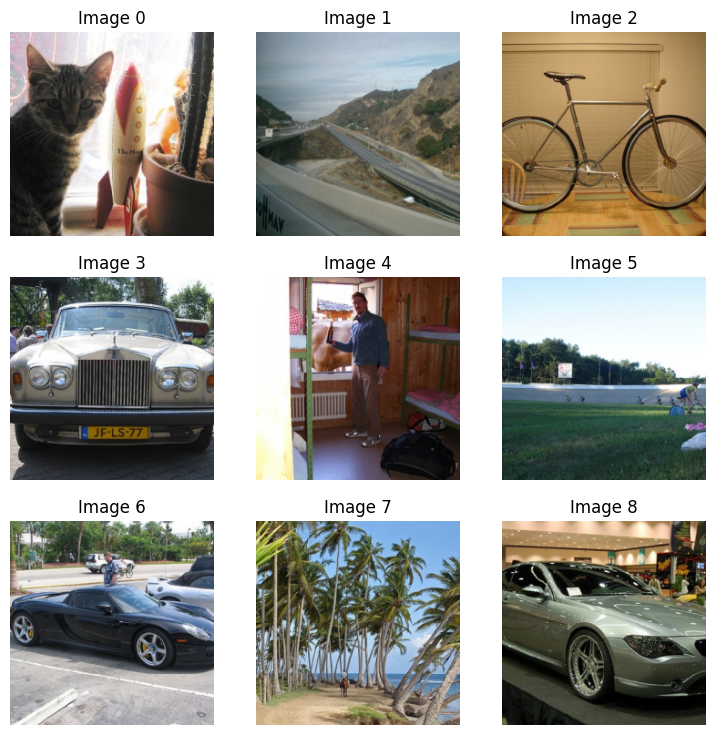

In [37]:
# Show worst classified samples
interp = Interpretation.from_learner(learn)
interp.plot_top_losses(9)

## Exercise 1: Train a DenseNet201 resizing images to 224x224 in the data augmentation phase